# 0 · Start here: a decision from logs

A ride-hailing team pays drivers a weekly incentive to go online. The team wants more drivers on
the road, and it has twelve weeks of logs from 200 regions. The question is a plan: **how much
incentive to pay in each of the next 15 weeks**, to lift driver supply to a target without
letting riders wait too long.

The logs hold a trap. The team raised the incentive in the weeks demand spiked, and demand
brings drivers online by itself. So in the logs, big incentives sit beside big supply gains that
demand caused. A model fitted to the logs gives the incentive the credit, and a plan made on it
pays too little.

This notebook walks the whole loop once, on simulated logs, so the true answer is known:

1. look at the logs and find the trap;
2. tell `chc` what causes what;
3. get a plan, with a certificate that says how far to trust it;
4. check the plan on the true system, against the plan from a naive fit;
5. see what `chc` does when the logs cannot answer the question.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)  # before any array exists
jax.config.update("jax_platforms", "cpu")  # the outputs below were made on a CPU

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from chc import CausalGraph, Constraint, Lever, Panel, Target, prescribe

## 1 · The logs

Each row is one region in one week:

- `supply`: drivers online, against normal;
- `wait`: how long riders wait, against normal;
- `incentive`: what the team paid that week, the lever;
- `demand`: how busy the week was.

The simulator below is the true system. A real team never sees it; here it lets us check every
answer. The incentive's true effect on supply growth is **0.8**.

In [2]:
DT = 0.1  # one logged week, in the model's time units


def simulate_logs(regions: int = 200, weeks: int = 12, seed: int = 0) -> dict[str, np.ndarray]:
    """A driver pool logged under a policy that raised the incentive whenever demand spiked."""
    rng = np.random.default_rng(seed)
    names = ("region", "week", "supply", "wait", "incentive", "demand")
    rows: dict[str, list[float]] = {name: [] for name in names}
    for region in range(regions):
        supply, wait = rng.normal(0.0, 0.2), rng.normal(0.0, 0.2)
        for week in range(weeks):
            demand = rng.normal(0.0, 1.0)
            incentive = 0.9 * demand + rng.normal(0.0, 0.5)  # the policy chases demand
            logged = (region, week, supply, wait, incentive, demand)
            for name, value in zip(names, logged, strict=True):
                rows[name].append(value)
            supply, wait = (
                supply
                + DT * (-0.6 * supply + 0.3 * wait + 0.8 * incentive + 1.5 * demand)
                + rng.normal(0.0, 0.01),
                wait + DT * (0.25 * wait - 0.4 * incentive) + rng.normal(0.0, 0.01),
            )
    return {name: np.asarray(values) for name, values in rows.items()}


logs = simulate_logs()
frame = pd.DataFrame(logs).astype({"region": int, "week": int})
frame.head(6).round(3)

,region,week,supply,wait,incentive,demand
0,0,0,0.025,-0.026,0.629,0.640
1,0,1,0.164,-0.049,1.647,1.304
2,0,2,0.473,-0.128,-0.540,-0.623
3,0,3,0.281,-0.112,-1.487,-1.246
4,0,4,-0.051,-0.059,0.892,0.412
5,0,5,0.082,-0.082,-0.423,-0.665


## 2 · The trap

Two plots of the same logs. On the left, the team paid more in busy weeks. On the right, each
dot is one region-week: the incentive paid, and how fast supply grew that week. The busy weeks,
in dark red, sit at the top right: demand pushed both numbers up together.

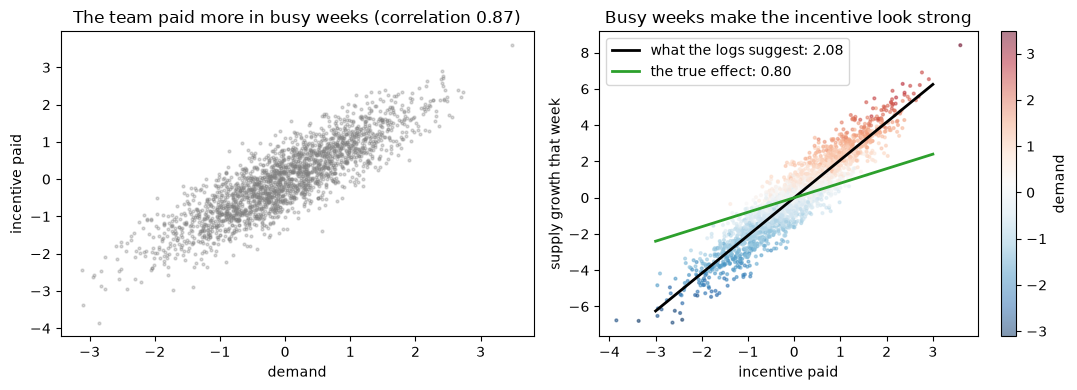

,effect of the incentive
fit on the logs as they are,2.083
fit that also reads demand,0.811
the truth,0.800


In [3]:
frame["growth"] = (frame.groupby("region")["supply"].shift(-1) - frame["supply"]) / DT
weeks = frame.dropna()  # the last week of each region has no next week to grow into


def effect_of_incentive(adjust_for: list[str]) -> float:
    """The incentive's coefficient in a least-squares fit of supply growth."""
    columns = ["supply", "wait", "incentive", *adjust_for]
    design = np.column_stack([np.ones(len(weeks)), weeks[columns].to_numpy()])
    coefficients = np.linalg.lstsq(design, weeks["growth"].to_numpy(), rcond=None)[0]
    return float(coefficients[1 + columns.index("incentive")])


naive, adjusted = effect_of_incentive([]), effect_of_incentive(["demand"])

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.scatter(weeks["demand"], weeks["incentive"], s=4, alpha=0.3, color="tab:gray")
left.set_xlabel("demand")
left.set_ylabel("incentive paid")
correlation = np.corrcoef(weeks["demand"], weeks["incentive"])[0, 1]
left.set_title(f"The team paid more in busy weeks (correlation {correlation:.2f})")
dots = right.scatter(
    weeks["incentive"], weeks["growth"], c=weeks["demand"], s=4, alpha=0.5, cmap="RdBu_r"
)
grid = np.linspace(-3.0, 3.0, 2)
right.plot(grid, naive * grid, color="black", lw=2, label=f"what the logs suggest: {naive:.2f}")
right.plot(grid, 0.8 * grid, color="tab:green", lw=2, label="the true effect: 0.80")
right.set_xlabel("incentive paid")
right.set_ylabel("supply growth that week")
right.set_title("Busy weeks make the incentive look strong")
right.legend(loc="upper left")
fig.colorbar(dots, ax=right, label="demand")
fig.tight_layout()
plt.show()

pd.DataFrame(
    {"effect of the incentive": [naive, adjusted, 0.8]},
    index=["fit on the logs as they are", "fit that also reads demand", "the truth"],
).round(3)

A fit on the logs as they are says the incentive is worth **2.6 times** what it is. A fit that
also reads demand gets it right, because it compares weeks of the same demand. That second fit
is called adjusting for demand, and demand is called a confounder.

Here the fix was easy, since we knew demand was the trap. On real logs, which columns to adjust
for is a causal question: adjusting for the wrong column can add a bias instead of removing one.
`chc` answers it from a graph you state.

## 3 · Tell `chc` what causes what

Each edge says "this moves that". The graph is an assumption, written down where a reviewer can
argue with it. From it, `chc` works out what to adjust for, and refuses when nothing in the logs
can separate the incentive's effect from demand's.

In [4]:
edges = [
    ("demand", "incentive"),  # the team looked at demand when it set the incentive
    ("demand", "supply"),  # busy weeks bring drivers online by themselves
    ("incentive", "supply"),  # the effect we want
    ("incentive", "wait"),  # more drivers, shorter waits
    ("wait", "supply"),  # long waits draw drivers in
]
graph = CausalGraph.from_edges(edges)
panel = Panel.from_frame(logs, unit="region", time="week", seed=0)

## 4 · The prescription

The decision, in the logs' own names:

- the lever: `incentive`, between -2 and 2 a week, priced at 0.05 times its square
  (`unit_cost`);
- the target: `supply` at 1.0, each week's miss costing its square;
- a limit: `wait` at most 0.5;
- 15 weeks of plan, and an error of 0.5 the plan may make before it stops being trusted.

In [5]:
decision = dict(
    levers=[Lever("incentive", lo=-2.0, hi=2.0, unit_cost=0.05)],
    target=Target("supply", value=1.0),
    constraints=[Constraint("wait", hi=0.5)],
    horizon=15,
    dt=DT,
    tolerance=0.5,
)
prescription = prescribe(panel, adjustment=graph, **decision)
print(prescription.report())

# Prescription for `supply`

## Decision

Start: the mean (standard deviation) over 200 units of each unit's last logged state, from period 11: `supply` 0.02264 (0.5971), `wait` 0.02703 (0.323).

| lever | active steps | first | last |
|---|---|---|---|
| `incentive` | 0-14 | +2 | +0.2552 |

Planned task cost: 2.02025.

## Certificate

- identification: **identified** (blocks every non-causal path from ['incentive'] to ['supply'])
- adjusted for: ['demand']
- estimability: **estimable**, the log moved 3 of the channel's 3 directions a state
- channel standard error: 0.008159, summed within 200 groups of `region`, within each of 11 periods, and within both, whichever reads largest (two-way CR1)
- overlap (residualised action variance): 0.2434
- logger check: passed (p = 0.46 over 11 periods); a pass can miss a partial correlation up to 0.079
- noise persistence: lag-1 autocorrelation -0.03 within units (p = 0.0997)
- error tube: **certified**, certified horizon 15, global rate
- barrier

The report has three parts. **Decision** is the schedule: when the lever is on, and how hard.
**Certificate** says how far to trust it, line by line:

- *identification*: the graph left one set to adjust for, `demand`, and the logs hold it;
- *channel standard error*: how precisely the logs pin the incentive's effect down, each
  region's weeks read as one group, since they share whatever the model leaves out;
- *overlap*: how much the incentive moved once demand is read; at 0 the logs teach nothing;
- *logger check*: whether the team's incentive followed anything the graph does not show; a
  pass can miss a weak link, and the line says how weak;
- *error tube*: for how many weeks the forecast's estimated error stays under the error you
  allowed (`tolerance`);
- *barrier*: for how many weeks the forecast keeps `wait` under its limit;
- *solver* and *regret bound*: whether the optimiser finished, and how far its plan can be from
  the best plan on the fitted model;
- *trustworthy prefix*: the weeks that pass every check, the number to act on.

**Provenance** pins the data and the version, so the numbers can be reproduced.

## 5 · Check the plan on the true system

A real team would now run the plan. Here we can run it on the simulator, with demand at its
average, and compare. We also make the plan a naive team would make: the same call with
`adjustment=()`, which asserts that nothing needs adjusting for.

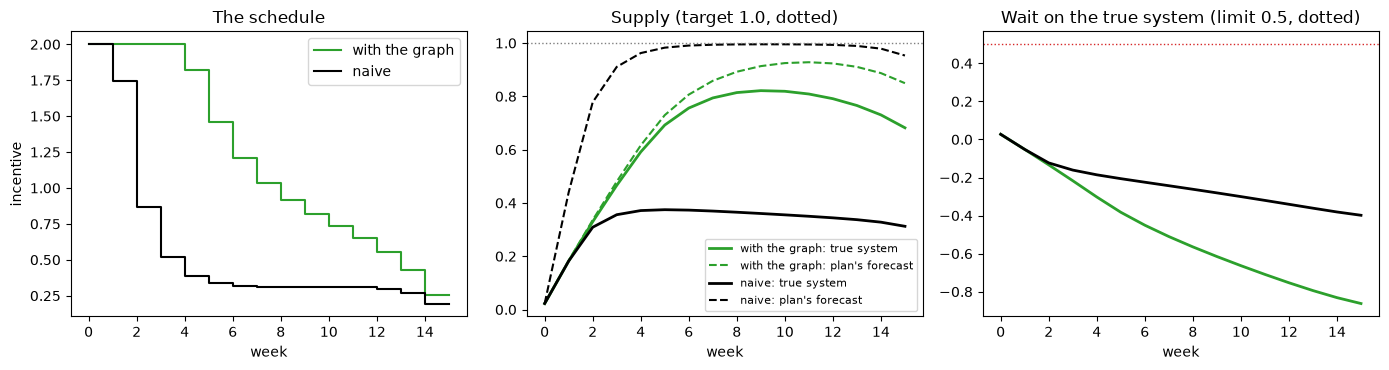

,incentive paid,weeks at the cap,"forecast above the truth, at most","true supply, best week","true supply, week 15",identification,trustworthy weeks
with the graph,17.888,4,0.167,0.821,0.682,identified,15
naive,8.503,1,0.652,0.375,0.312,asserted,0


In [6]:
def true_path(start: np.ndarray, incentives: np.ndarray) -> np.ndarray:
    """Supply and wait on the true system under a schedule, from `start`, with demand at 0."""
    supply, wait = start
    path = [(supply, wait)]
    for incentive in incentives:
        supply, wait = (
            supply + DT * (-0.6 * supply + 0.3 * wait + 0.8 * incentive),
            wait + DT * (0.25 * wait - 0.4 * incentive),
        )
        path.append((supply, wait))
    return np.asarray(path)


naive_prescription = prescribe(panel, adjustment=(), **decision)

plans = {"with the graph": prescription, "naive": naive_prescription}
paths = {}
for name, result in plans.items():
    schedule = np.asarray(result.plan.actions)[:, 0]
    forecast = np.asarray(result.plan.trajectory)  # the plan's own forecast: supply, then wait
    paths[name] = (schedule, forecast, true_path(forecast[0], schedule))

steps = np.arange(16)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for (name, (schedule, forecast, truth)), color in zip(
    paths.items(), ("tab:green", "black"), strict=True
):
    axes[0].step(steps, np.append(schedule, schedule[-1]), where="post", color=color, label=name)
    axes[1].plot(steps, truth[:, 0], color=color, lw=2, label=f"{name}: true system")
    axes[1].plot(steps, forecast[:, 0], color=color, ls="--", label=f"{name}: plan's forecast")
    axes[2].plot(steps, truth[:, 1], color=color, lw=2, label=name)
axes[0].set_title("The schedule")
axes[0].set_ylabel("incentive")
axes[1].axhline(1.0, color="tab:gray", lw=1, ls=":")
axes[1].set_title("Supply (target 1.0, dotted)")
axes[2].axhline(0.5, color="tab:red", lw=1, ls=":")
axes[2].set_title("Wait on the true system (limit 0.5, dotted)")
for ax in axes:
    ax.set_xlabel("week")
axes[0].legend()
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

pd.DataFrame(
    {
        "incentive paid": [paths[name][0].sum() for name in plans],
        "weeks at the cap": [int(np.sum(paths[name][0] > 2.0 - 1e-6)) for name in plans],
        "forecast above the truth, at most": [
            np.max(paths[name][1][:, 0] - paths[name][2][:, 0]) for name in plans
        ],
        "true supply, best week": [paths[name][2][:, 0].max() for name in plans],
        "true supply, week 15": [paths[name][2][-1, 0] for name in plans],
        "identification": [plans[name].certificate.identification for name in plans],
        "trustworthy weeks": [plans[name].certificate.trustworthy_steps for name in plans],
    },
    index=list(plans),
).round(3)

The naive plan believes the incentive is 2.6 times as strong as it is. So it pays about half as
much, and on the true system supply gets less than halfway to where the plan with the graph takes
it. Its own forecast, the dashed black line, promised the target. `chc` would not have vouched
for it: with nothing adjusted for, the fit is the logs' correlation, so no error bound is
computed and the trustworthy prefix is 0 weeks.

The plan with the graph pays the cap for four weeks, then tapers. Each week it weighs the miss
against the incentive's price, so it settles short of 1.0; near the end, an incentive has too
little time left to move supply inside the 15 weeks. Its forecast, the dashed green line, runs
above the truth by up to 0.17. The logs pin the incentive's effect down well, as the small
standard error in the report says. What supply does on its own is fitted less precisely: the
logs' demand shocks are large next to it. The gap stays under the error of 0.5 the plan was
allowed, so its 15 trustworthy weeks held here.

## 6 · When the logs cannot answer

Now suppose demand was never logged. The graph says so with `latent=`. No set of logged columns
separates the incentive's effect from demand's, so `chc` makes **no plan**, and says why: in a
warning, the first line below, and in the report.

In [7]:
blind = prescribe(panel, adjustment=CausalGraph.from_edges(edges, latent=("demand",)), **decision)
print(blind.certificate.identification)
print(blind.report().split("## Certificate")[0])

no schedule: no observed set identifies the effect


not_identified
# Prescription for `supply`

## Decision

Start: the mean (standard deviation) over 200 units of each unit's last logged state, from period 11: `supply` 0.02264 (0.5971), `wait` 0.02703 (0.323).

**No schedule.** no observed set blocks every non-causal path; latent ['demand'] confounds it




Refusing is the point. A plan made on the confounded fit would look as confident as the naive
one above, and be as wrong. What to do instead: log the confounder, find an instrument, or run
an experiment. The other notebooks show each.

## Where next

- [1 · Causal vs predictive control](https://causaldyn.github.io/causal-hybrid-control/tutorials/01_causal_vs_predictive_control/): the
  same trap, and a predictive controller it drives off a cliff;
- [5 · Robust control under hidden confounding](https://causaldyn.github.io/causal-hybrid-control/tutorials/05_confounding_robust_control/):
  a plan when the confounder was never logged, priced at a sensitivity level;
- [8 · Splitting an advertising budget](https://causaldyn.github.io/causal-hybrid-control/tutorials/08_splitting_a_budget/) and
  [9 · Heating a room on a winter night](https://causaldyn.github.io/causal-hybrid-control/tutorials/09_heating_a_room/): two more everyday
  decisions;
- the [quickstart](https://causaldyn.github.io/causal-hybrid-control/quickstart/): every
  argument of `prescribe`, and the expert path without it.